In [1]:
import os
import sys
from pathlib import Path

import numpy as np


In [2]:
folder_path = Path(os.getcwd()).parent
sys.path.append(str(folder_path))

In [3]:
from util.parse_loc import parse_forecast_file

In [4]:
data_folder = folder_path / "forecast_price"

In [5]:
crops = {
    "Cassava": "cassava_forecast.txt",
    "Corn": "corn_forecast.txt",
    "Green Bean": "green_bean_forecast.txt",
    "Soybean": "soybean_forecast.txt",
}

In [6]:
crop_data = {}

for crop_name, file_name in crops.items():
    file_path = data_folder / file_name

    if os.path.exists(file_path):
        dates, prices = parse_forecast_file(file_path)
        crop_data[crop_name] = {"dates": dates, "prices": prices}
        print(f"Loaded {crop_name} data: {len(prices)} price points")
    else:
        print(f"Warning: {file_path} not found")

print(f"\nLoaded data for {len(crop_data)} crops")

Loaded Cassava data: 12 price points
Loaded Corn data: 12 price points
Loaded Green Bean data: 12 price points
Loaded Soybean data: 12 price points

Loaded data for 4 crops


In [7]:
crop_price_avg = {}

for crop_name, data in crop_data.items():
    dates = data["dates"]
    prices = data["prices"]

    if len(prices) > 0:
        avg_price = np.round(np.mean(prices), 2)
        crop_price_avg[crop_name] = avg_price
        print(f"{crop_name} average price: {avg_price:.2f}")
    else:
        print(f"No price data available for {crop_name}")


Cassava average price: 3.00
Corn average price: 11.22
Green Bean average price: 24.64
Soybean average price: 18.42


In [8]:
print(crop_price_avg["Cassava"])
print(crop_price_avg["Corn"])
print(crop_price_avg["Green Bean"])
print(crop_price_avg["Soybean"])

3.0
11.22
24.64
18.42


In [9]:
for crop_name, data in crop_data.items():
    print(f"{crop_data[crop_name]['prices']}")

[3.5, 3.31, 3.21, 3.14, 3.07, 3.0, 2.93, 2.87, 2.81, 2.75, 2.7, 2.66]
[10.71, 11.12, 11.34, 11.38, 11.31, 11.21, 11.16, 11.16, 11.21, 11.28, 11.35, 11.41]
[21.92, 22.42, 24.3, 24.77, 25.11, 25.19, 25.18, 25.25, 25.28, 25.3, 25.4, 25.52]
[16.79, 17.58, 19.31, 19.65, 19.25, 17.8, 17.68, 18.52, 18.61, 18.6, 18.67, 18.55]


In [10]:
crops_income = {}
income_multiplication = {
    "Cassava": 3500,
    "Corn": 2500,
    "Green Bean": 245,
    "Soybean": 300,
}

for crop_name, data in crop_data.items():
    price_lst = crop_data[crop_name]["prices"]
    income_lst = []
    for price in price_lst:
        income_lst.append(price * income_multiplication[crop_name])

    crops_income[crop_name] = income_lst

print(crops_income)

{'Cassava': [12250.0, 11585.0, 11235.0, 10990.0, 10745.0, 10500.0, 10255.0, 10045.0, 9835.0, 9625.0, 9450.0, 9310.0], 'Corn': [26775.000000000004, 27799.999999999996, 28350.0, 28450.000000000004, 28275.0, 28025.000000000004, 27900.0, 27900.0, 28025.000000000004, 28200.0, 28375.0, 28525.0], 'Green Bean': [5370.400000000001, 5492.900000000001, 5953.5, 6068.65, 6151.95, 6171.55, 6169.1, 6186.25, 6193.6, 6198.5, 6223.0, 6252.4], 'Soybean': [5037.0, 5273.999999999999, 5793.0, 5895.0, 5775.0, 5340.0, 5304.0, 5556.0, 5583.0, 5580.0, 5601.000000000001, 5565.0]}


In [ ]:
import matplotlib.pyplot as plt


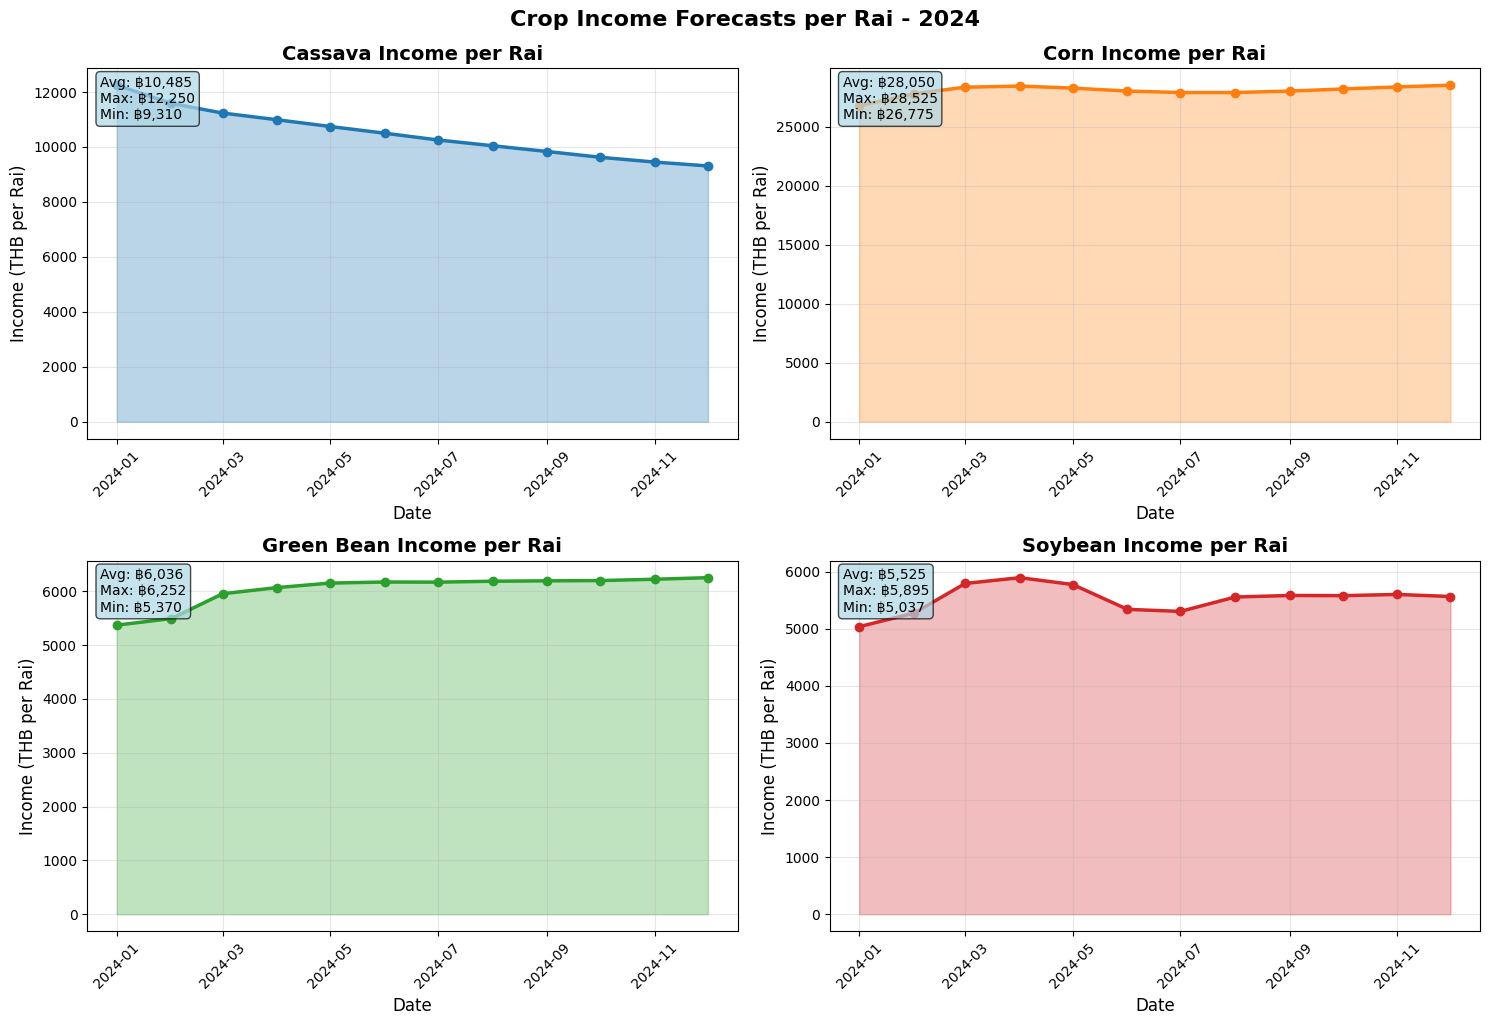

In [12]:
# Configuration for plotting
plt.style.use("default")
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
crop_names = list(crops_income.keys())

# Create figure with subplots for individual crop income plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Plot individual income graphs for each crop
for i, (crop_name, income_data) in enumerate(crops_income.items()):
    dates = crop_data[crop_name]["dates"]

    axes[i].plot(
        dates, income_data, color=colors[i], linewidth=2.5, marker="o", markersize=6
    )
    axes[i].fill_between(dates, income_data, alpha=0.3, color=colors[i])
    axes[i].set_title(f"{crop_name} Income per Rai", fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Date", fontsize=12)
    axes[i].set_ylabel("Income (THB per Rai)", fontsize=12)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis="x", rotation=45)

    # Add statistics
    avg_income = np.mean(income_data)
    max_income = np.max(income_data)
    min_income = np.min(income_data)

    axes[i].text(
        0.02,
        0.98,
        f"Avg: ฿{avg_income:,.0f}\nMax: ฿{max_income:,.0f}\nMin: ฿{min_income:,.0f}",
        transform=axes[i].transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7),
    )

plt.tight_layout()
plt.suptitle(
    "Crop Income Forecasts per Rai - 2024", fontsize=16, fontweight="bold", y=1.02
)
plt.show()